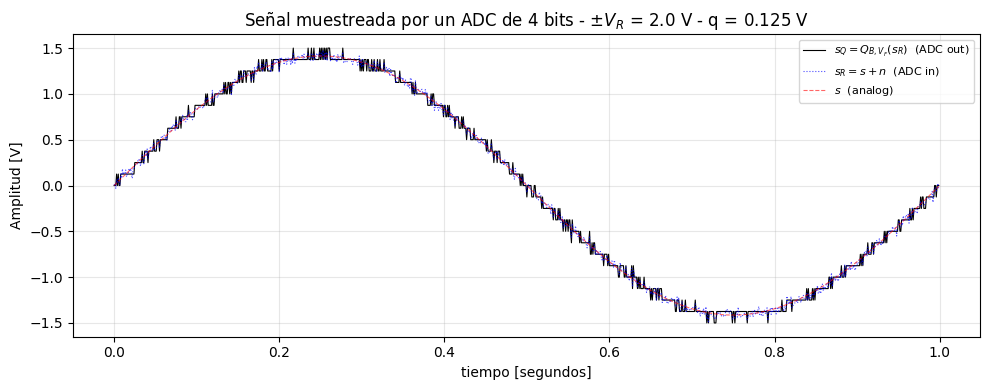

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Función auxiliar (consistente con TS1) ─────────────────────
def mi_funcion_sen(vmax, dc, f0, N, fs, ph=0):
    ts = 1 / fs
    tt = np.linspace(0, (N - 1) * ts, N)
    xx = dc + vmax * np.sin(2 * np.pi * f0 * tt + ph)
    return tt, xx

def calcular_dep_dB(x, N, fs):
    """Densidad espectral de potencia unilateral en dB."""
    X      = np.fft.fft(x) / N
    X      = X[:N // 2]
    dep    = np.abs(X) ** 2
    dep[1:] *= 2                          # espectro unilateral
    dep_dB = 10 * np.log10(dep + 1e-20)  # +eps evita log(0)
    freq   = np.fft.fftfreq(N, 1 / fs)[:N // 2]
    return freq, dep_dB

# ── Parámetros globales del ADC ────────────────────────────────
fs = 1000        # Hz — frecuencia de muestreo del ADC (dato de la consigna)
f0 = 1           # Hz — f0 = fs/N = Δf (un ciclo exacto en la ventana → sin leakage)
N  = 1000        # muestras → duración = 1 s
vmax = np.sqrt(2)  # V — energía normalizada: var(s) = vmax²/2 = 1 W
dc = 0
Ts = 1 / fs      # = 0.001 s
df = fs / N      # = 1 Hz
VF = 2           # Volts — rango ±VF del ADC

#%% ============================================================
# PARTE a)  B = 4 bits,  kn = 1
# ============================================================

B  = 4
kn = 1

# ── Senoidal con energía normalizada (varianza = 1) ────────────
# var(senoidal) = vmax²/2 → para var=1 se necesita vmax = √2 (definido arriba)
tt, s = mi_funcion_sen(vmax, dc, f0, N, fs)

assert np.isclose(np.var(s), 1.0, atol=1e-3), "Varianza ≠ 1"

# ── Parámetros de cuantización ─────────────────────────────────
q  = VF / (2 ** B)          # paso de cuantización (VF = amplitud máxima, 2^B niveles)
Pq = q ** 2 / 12            # potencia teórica del ruido de cuantización

# ── Ruido aditivo Gaussiano incorrelado ───────────────────────
Pn = kn * Pq
noise = np.random.normal(0, np.sqrt(Pn), N)
sR = s + noise

# ── Cuantización ───────────────────────────────────────────────
sR_clip = np.clip(sR, -VF, VF)
idx     = np.floor(sR_clip / q + 0.5)   # redondeo al nivel más cercano
sQ      = idx * q

# ── Figura 1: señal en el tiempo ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(tt, sQ,  'k-',  lw=0.8, label=r'$s_Q = Q_{B,V_F}(s_R)$  (ADC out)')
ax1.plot(tt, sR,  'b:',  lw=0.8, label=r'$s_R = s + n$  (ADC in)',  alpha=0.7)
ax1.plot(tt, s,   'r--', lw=0.8, label=r'$s$  (analog)',             alpha=0.6)
ax1.set_title(
    f'Señal muestreada por un ADC de {B} bits - '
    f'$\\pm V_R$ = {VF:.1f} V - q = {q:.3f} V'
)
ax1.set_xlabel('tiempo [segundos]')
ax1.set_ylabel('Amplitud [V]')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
plt.show()

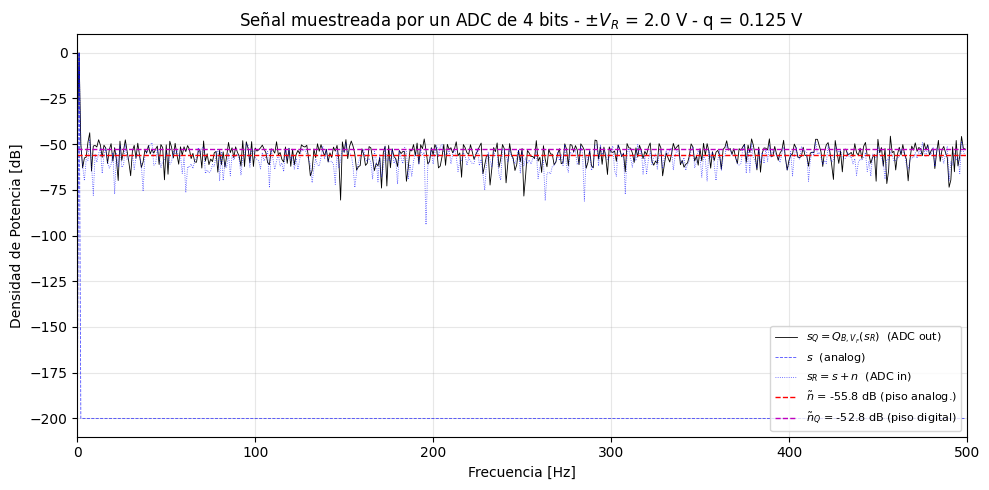

In [2]:
#%% ── Figura 2: DEP / espectro de potencia ───────────────────

freq, dep_sQ = calcular_dep_dB(sQ, N, fs)
freq, dep_s  = calcular_dep_dB(s,  N, fs)
freq, dep_sR = calcular_dep_dB(sR, N, fs)

piso_analogico = 10 * np.log10(Pn / (fs / 2))
piso_digital   = 10 * np.log10((Pn + Pq) / (fs / 2))

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(freq, dep_sQ, 'k-',  lw=0.6, label=r'$s_Q = Q_{B,V_F}(s_R)$  (ADC out)')
ax2.plot(freq, dep_s,  'b--', lw=0.6, label=r'$s$  (analog)',            alpha=0.7)
ax2.plot(freq, dep_sR, 'b:',  lw=0.6, label=r'$s_R = s + n$  (ADC in)', alpha=0.7)
ax2.axhline(piso_analogico, color='r', lw=1, ls='--',
            label=f'$\\tilde n$ = {piso_analogico:.1f} dB (piso analog.)')
ax2.axhline(piso_digital,   color='m', lw=1, ls='--',
            label=f'$\\tilde n_Q$ = {piso_digital:.1f} dB (piso digital)')
ax2.set_title(
    f'Señal muestreada por un ADC de {B} bits - '
    f'$\\pm V_R$ = {VF:.1f} V - q = {q:.3f} V'
)
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de Potencia [dB]')
ax2.set_xlim(0, fs / 2)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

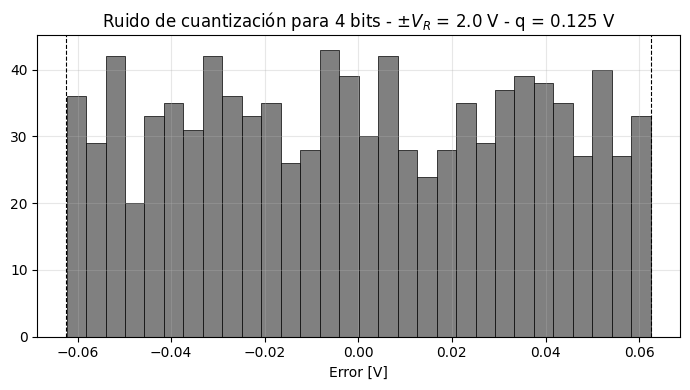


=== Parte a) B=4, kn=1 ===
  q         = 0.1250 V
  Pq        = 0.001302 W  (-28.85 dB)
  Pn        = 0.001302 W  (-28.85 dB)
  Piso ana  = -55.84 dB
  Piso dig  = -52.83 dB


In [3]:
#%% ── Figura 3: histograma del ruido de cuantización ─────────

error_q = sR_clip - sQ

fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.hist(error_q, bins=30, color='gray', edgecolor='k', linewidth=0.5)
ax3.axvline(-q / 2, color='k', ls='--', lw=0.8)
ax3.axvline( q / 2, color='k', ls='--', lw=0.8)
ax3.set_title(
    f'Ruido de cuantización para {B} bits - '
    f'$\\pm V_R$ = {VF:.1f} V - q = {q:.3f} V'
)
ax3.set_xlabel('Error [V]')
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()

print(f"\n=== Parte a) B={B}, kn={kn} ===")
print(f"  q         = {q:.4f} V")
print(f"  Pq        = {Pq:.6f} W  ({10*np.log10(Pq):.2f} dB)")
print(f"  Pn        = {Pn:.6f} W  ({10*np.log10(Pn):.2f} dB)")
print(f"  Piso analogico  = {piso_analogico:.2f} dB")
print(f"  Piso digital  = {piso_digital:.2f} dB")


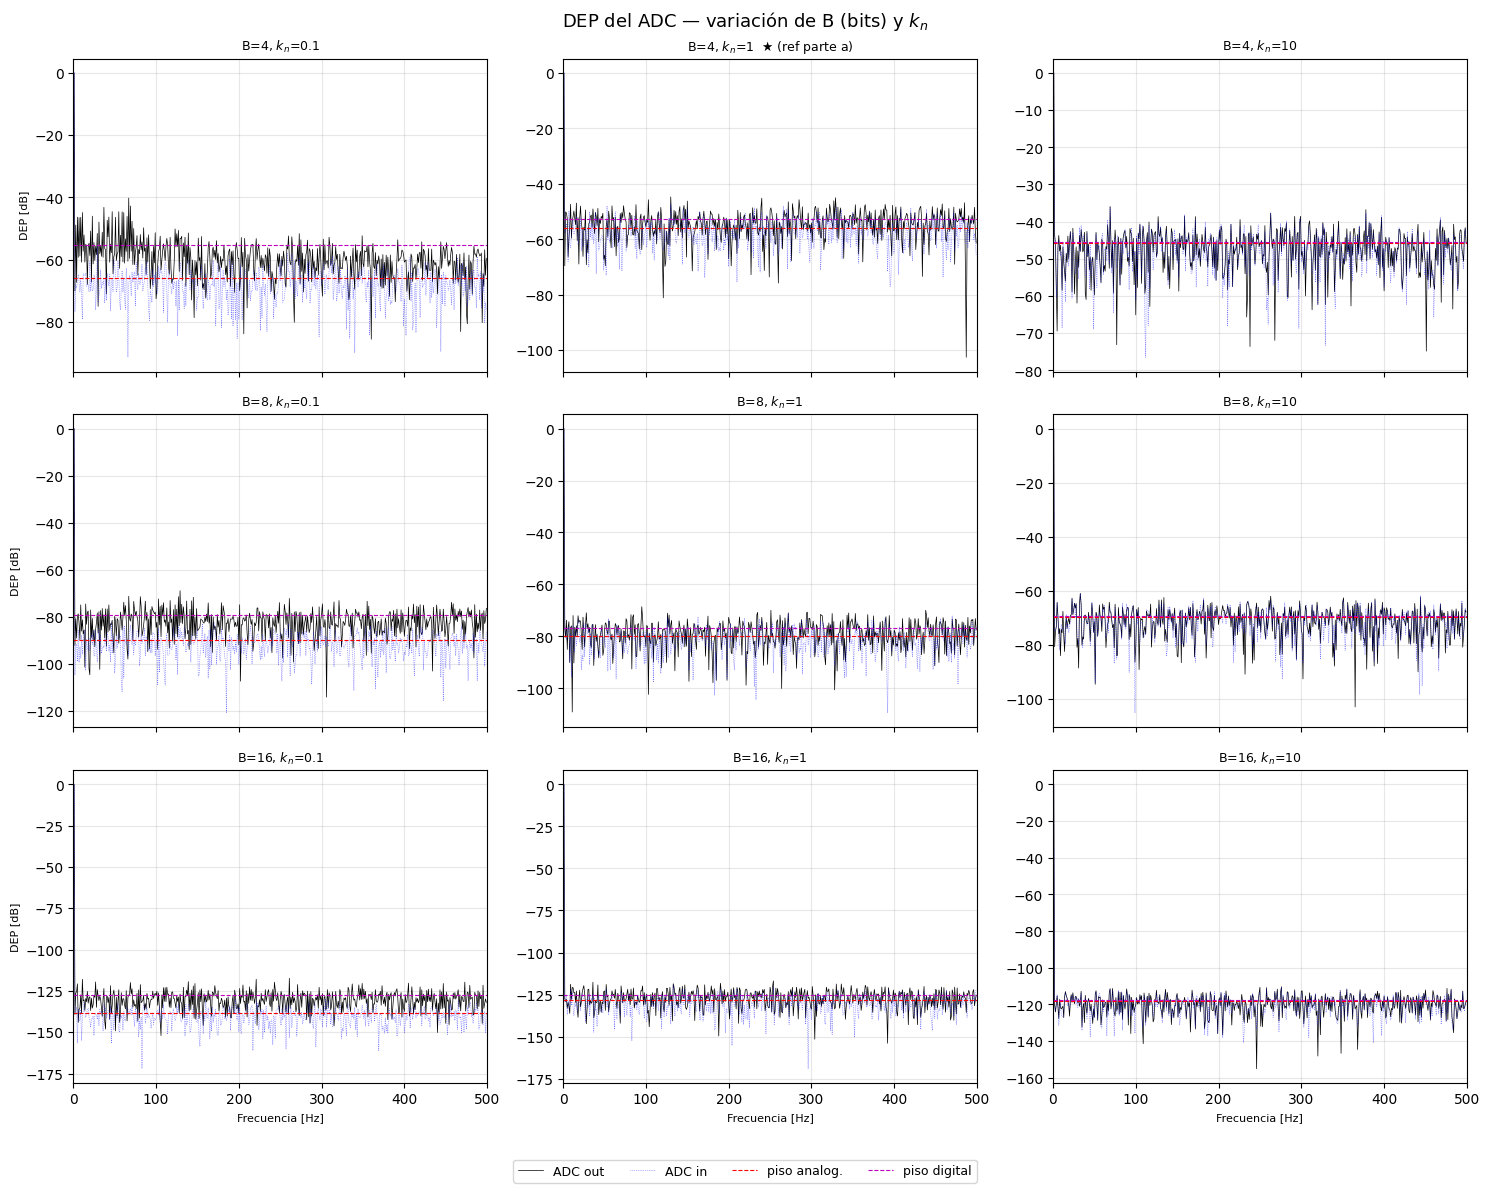

In [4]:
#%% ============================================================
# PARTE b)  B ∈ {4, 8, 16},  kn ∈ {1/10, 1, 10}
# ============================================================

B_vals  = [4, 8, 16]
kn_vals = [1/10, 1, 10]

fig_b, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=False)
fig_b.suptitle('DEP del ADC — variación de B (bits) y $k_n$', fontsize=13)

for i, B_b in enumerate(B_vals):
    for j, kn_b in enumerate(kn_vals):

        ax = axes[i][j]

        q_b   = VF / (2 ** B_b)
        Pq_b  = q_b ** 2 / 12
        Pn_b  = kn_b * Pq_b

        noise_b   = np.random.normal(0, np.sqrt(Pn_b), N)
        sR_b      = s + noise_b
        sR_b_clip = np.clip(sR_b, -VF, VF)
        idx_b     = np.floor(sR_b_clip / q_b + 0.5)
        sQ_b      = idx_b * q_b

        freq_b, dep_sQ_b = calcular_dep_dB(sQ_b, N, fs)
        _,      dep_sR_b = calcular_dep_dB(sR_b,  N, fs)

        piso_a_b = 10 * np.log10(Pn_b / (fs / 2))
        piso_d_b = 10 * np.log10((Pn_b + Pq_b) / (fs / 2))

        ax.plot(freq_b, dep_sQ_b, 'k-',  lw=0.5, label='ADC out')
        ax.plot(freq_b, dep_sR_b, 'b:',  lw=0.5, label='ADC in',  alpha=0.6)
        ax.axhline(piso_a_b, color='r', lw=0.8, ls='--', label=f'{piso_a_b:.0f} dB')
        ax.axhline(piso_d_b, color='m', lw=0.8, ls='--', label=f'{piso_d_b:.0f} dB')

        titulo = f'B={B_b}, $k_n$={kn_b}'
        if B_b == 4 and kn_b == 1:
            titulo += '  ★ (ref parte a)'
        ax.set_title(titulo, fontsize=9)
        ax.set_xlim(0, fs / 2)
        ax.grid(True, alpha=0.3)

        if j == 0:
            ax.set_ylabel('DEP [dB]', fontsize=8)
        if i == 2:
            ax.set_xlabel('Frecuencia [Hz]', fontsize=8)

handles, labels = axes[0][0].get_legend_handles_labels()
fig_b.legend(handles, ['ADC out', 'ADC in', 'piso analog.', 'piso digital'],
             loc='lower center', ncol=4, fontsize=9)
fig_b.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()